In [5]:
G = nx.DiGraph()

for row in edges.itertuples(index=False):
    G.add_edge(
        str(row.Source),
        str(row.Target),
        weight=float(row.Weight)
    )

print("Full graph nodes:", G.number_of_nodes())
print("Full graph edges:", G.number_of_edges())

Full graph nodes: 60532
Full graph edges: 109443


In [6]:
pagerank = nx.pagerank(
    G,
    alpha=0.85,
    weight="weight"
)

top_100 = sorted(
    pagerank,
    key=pagerank.get,
    reverse=True
)[:100]

print("Top 20 PageRank users:")

for rank, user in enumerate(top_100[:20], start=1):
    print(
        rank,
        user,
        round(pagerank[user], 6)
    )

Top 20 PageRank users:
1 narendramodi 0.047735
2 RahulGandhi 0.012123
3 ikamalhaasan 0.011791
4 BJP4India 0.007007
5 ArvindKejriwal 0.006402
6 INCIndia 0.00559
7 kcvenugopalmp 0.005255
8 AmitShah 0.004241
9 BCCI 0.003938
10 ANI 0.003558
11 PMOIndia 0.003255
12 ShashiTharoor 0.002321
13 ashoswai 0.001956
14 sardesairajdeep 0.001832
15 CasMudde 0.001816
16 SupriyaShrinate 0.00175
17 AamAadmiParty 0.001634
18 Indian_Analyzer 0.001534
19 PawarSpeaks 0.001465
20 RishiSunak 0.00142


In [7]:
H = G.subgraph(top_100).copy()

# Remove self-loops only for visualization clarity
H.remove_edges_from(nx.selfloop_edges(H))

print("Top-100 nodes:", H.number_of_nodes())
print("Connections among Top-100:", H.number_of_edges())

Top-100 nodes: 100
Connections among Top-100: 47


In [8]:
H_undirected = H.to_undirected()

communities = list(
    nx.community.greedy_modularity_communities(
        H_undirected,
        weight="weight"
    )
)

community_id = {}

for idx, community in enumerate(communities):
    for node in community:
        community_id[node] = idx

print("Communities detected:", len(communities))

Communities detected: 68


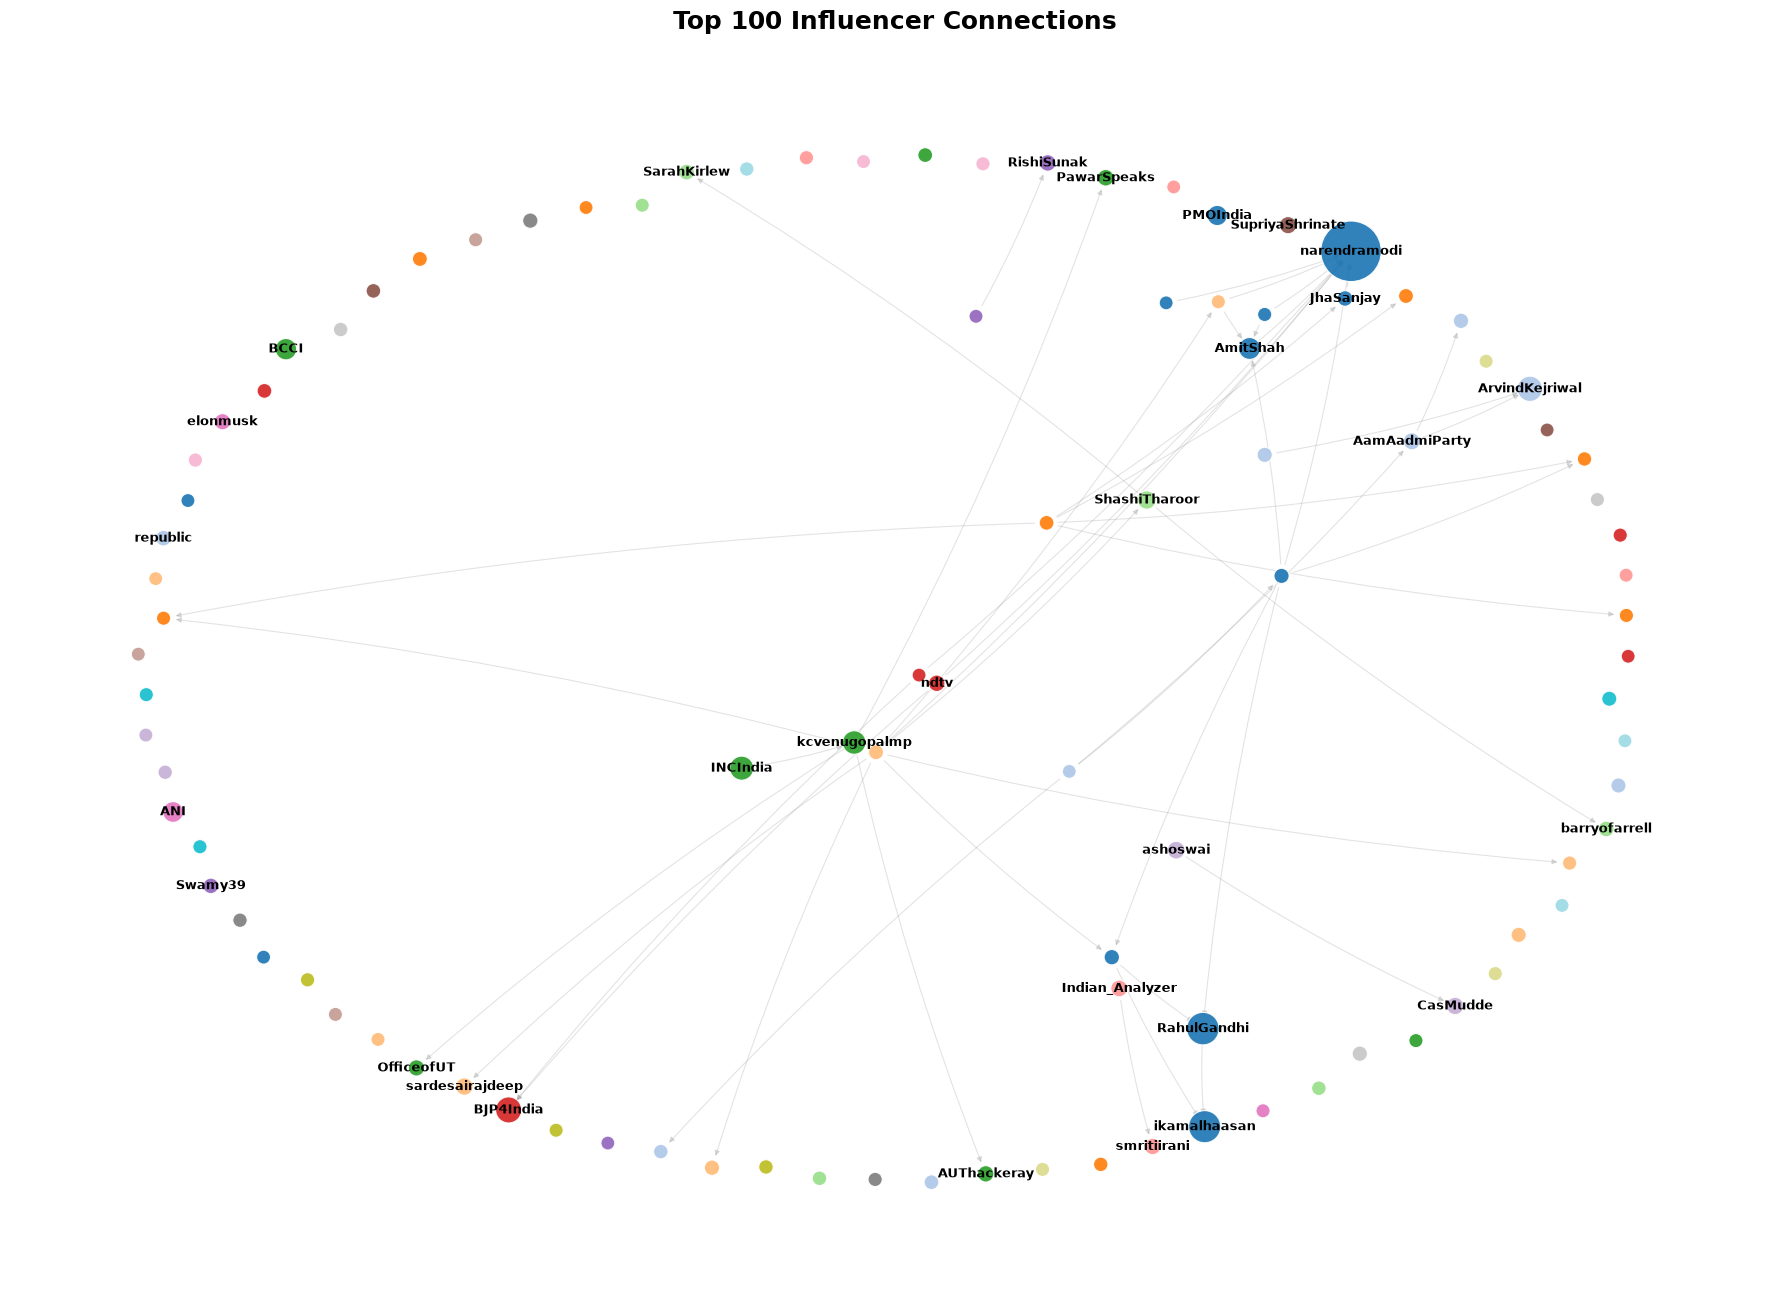

Saved: C:\Users\Nikhil\Documents\sentiment_graph_diffusion\results\figures\top_100_influencer_connections_generated.png


In [9]:
# -----------------------------
# Layout
# -----------------------------
pos = nx.spring_layout(
    H,
    seed=42,
    k=1.4,
    iterations=300,
    weight="weight"
)

# -----------------------------
# Node sizes based on PageRank
# -----------------------------
pr_values = np.array([pagerank[node] for node in H.nodes()])

pr_min = pr_values.min()
pr_max = pr_values.max()

if pr_max > pr_min:
    scaled = (pr_values - pr_min) / (pr_max - pr_min)
else:
    scaled = np.ones_like(pr_values)

node_sizes = 100 + (scaled * 1800)

# -----------------------------
# Community colors
# -----------------------------
cmap = plt.get_cmap("tab20")

node_colors = [
    cmap(community_id.get(node, 0) % 20)
    for node in H.nodes()
]

# -----------------------------
# Label only important users
# -----------------------------
top_label_nodes = set(top_100[:30])

labels = {
    node: node
    for node in H.nodes()
    if node in top_label_nodes
}

# -----------------------------
# Draw
# -----------------------------
plt.figure(figsize=(18, 13))

nx.draw_networkx_edges(
    H,
    pos,
    edge_color="gray",
    alpha=0.22,
    width=0.8,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=8,
    connectionstyle="arc3,rad=0.04"
)

nx.draw_networkx_nodes(
    H,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.92,
    linewidths=0.8,
    edgecolors="white"
)

nx.draw_networkx_labels(
    H,
    pos,
    labels=labels,
    font_size=9,
    font_weight="bold"
)

plt.title(
    "Top 100 Influencer Connections",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.axis("off")
plt.tight_layout()

output_path = figures_dir / "top_100_influencer_connections_generated.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", output_path)

In [3]:
edges = pd.read_csv(edges_path)

print("Shape:", edges.shape)
display(edges.head())

print("\nColumns:")
print(edges.columns.tolist())

Shape: (109443, 3)


,Source,Target,Weight
0,LaksshyaAdvani,narendramodi,151
1,kumardurgesh262,narendramodi,129
2,TOIAhmedabad,narendramodi,92
3,spkathirvel1,EPSTamilNadu,60
4,TriptiRTiwari,narendramodi,59



Columns:
['Source', 'Target', 'Weight']


In [4]:
from pathlib import Path

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Project root
root = Path(r"C:\Users\Nikhil\Documents\sentiment_graph_diffusion")

raw_dir = root / "data" / "raw"
figures_dir = root / "results" / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

edges_path = raw_dir / "network_edges.csv"

print("Edge file:", edges_path)
print("Figure output:", figures_dir)

Edge file: C:\Users\Nikhil\Documents\sentiment_graph_diffusion\data\raw\network_edges.csv
Figure output: C:\Users\Nikhil\Documents\sentiment_graph_diffusion\results\figures
